In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from collections import Counter

In [3]:
with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)
    
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)
    
with open("/data/zachkaras/fmri_model_data/intermediate_results/all_results.pkl", 'rb') as f:
    records = pickle.load(f)
    
# inpath = '/data/zachkaras/fmri_model_data/intermediate_results' 
# with open(f"{inpath}/enrichment_analysis_results.pkl", 'rb') as f:
#     enriched_parcels = pickle.load(f)

In [ ]:

# records['top_parcels']
# TODO - need to do this translation on the records

In [25]:
important_participants = ['117', '125', '108']

def translate_to_region_names(parcel_num, schaefer_labels):
        parcel_num = int(parcel_num)
        if parcel_num <= 200:
            region = f"Left {schaefer_labels['left'][parcel_num]}"
        else:
            region = f"Right {schaefer_labels['right'][parcel_num]}"
        return region

def get_top_five_regions(parcel_dict):
    parcel_dict = dict(sorted(parcel_dict.items(), key= lambda x: x[1], reverse=True))
    return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < 5}

def plot_participant_parcels_across_layers(p, model, task, parcel_dict, region_colors):
    # Build rows, sorting each layer's regions by score descending
    rows = []
    for _, row in parcel_dict.iterrows():
        layer = str(row['layer'])
        sorted_regions = sorted(row['top_five_regions'].items(), key=lambda x: x[1], reverse=True)[:5]
        for rank, (region, val) in enumerate(sorted_regions):
            rows.append({'layer': layer, 'region': region, 'score': val, 'rank': rank})
    df = pd.DataFrame(rows)
    # print(df)

    layers = sorted(df['layer'].unique(), key=lambda x: int(x.split('_')[1]))

    n_bars = 5
    bar_width = 0.15
    gap = 0.3  # extra space between groups

    fig, ax = plt.subplots(figsize=(14, 8))
    group_centers = []

    for g_idx, layer in enumerate(layers):
        layer_df = df[df['layer'] == layer].sort_values('score', ascending=False)
        n = len(layer_df)
        offsets = np.arange(n) * bar_width - (n - 1) * bar_width / 2
        center = g_idx * (n_bars * bar_width + gap)
        group_centers.append(center)
        for b_idx, (_, r) in enumerate(layer_df.iterrows()):
            ax.bar(center + offsets[b_idx], r['score'], width=bar_width,
                   color=region_colors[r['region']], edgecolor='black',
                   label=r['region'])

    # Deduplicated legend (first occurrence of each region)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Region", loc='upper right', fontsize=10)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(layers, rotation=45, ha='right')
    ax.set_xlabel("Layer")
    # ax.set_ylim([0, 25])
    ax.set_ylabel("Top Regions")
    ax.set_title(f"{p} - Top Regions Modeled Per Layer\n{model}-{task}")
    plt.tight_layout()
    plt.show()

In [29]:
all_regions_global = set()
for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        for top_five in df['top_five_regions']:
            all_regions_global.update(top_five.keys())

all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
palette = sns.color_palette("rainbow", len(all_regions_global))
rng = np.random.default_rng(seed=1) # 111 is pretty good
rng.shuffle(palette)
region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

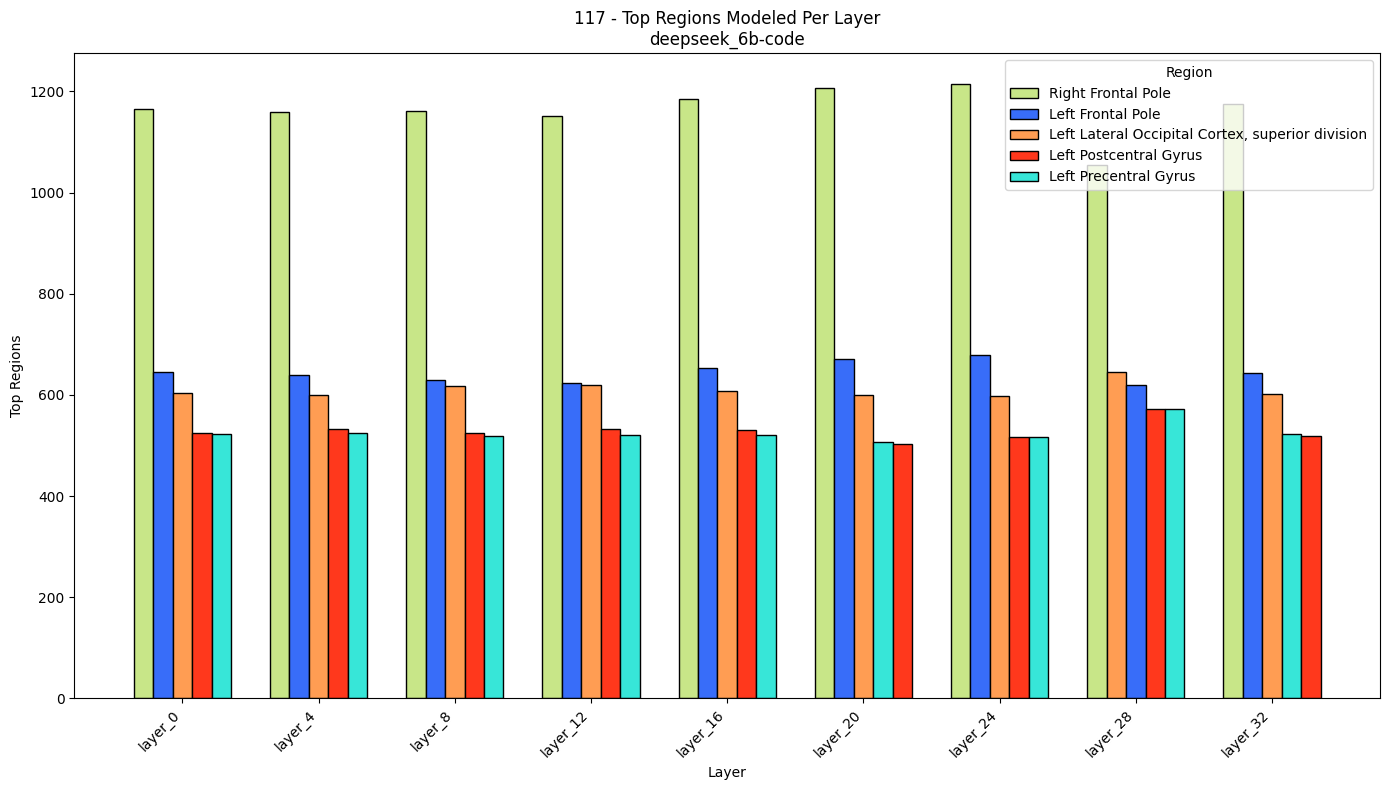

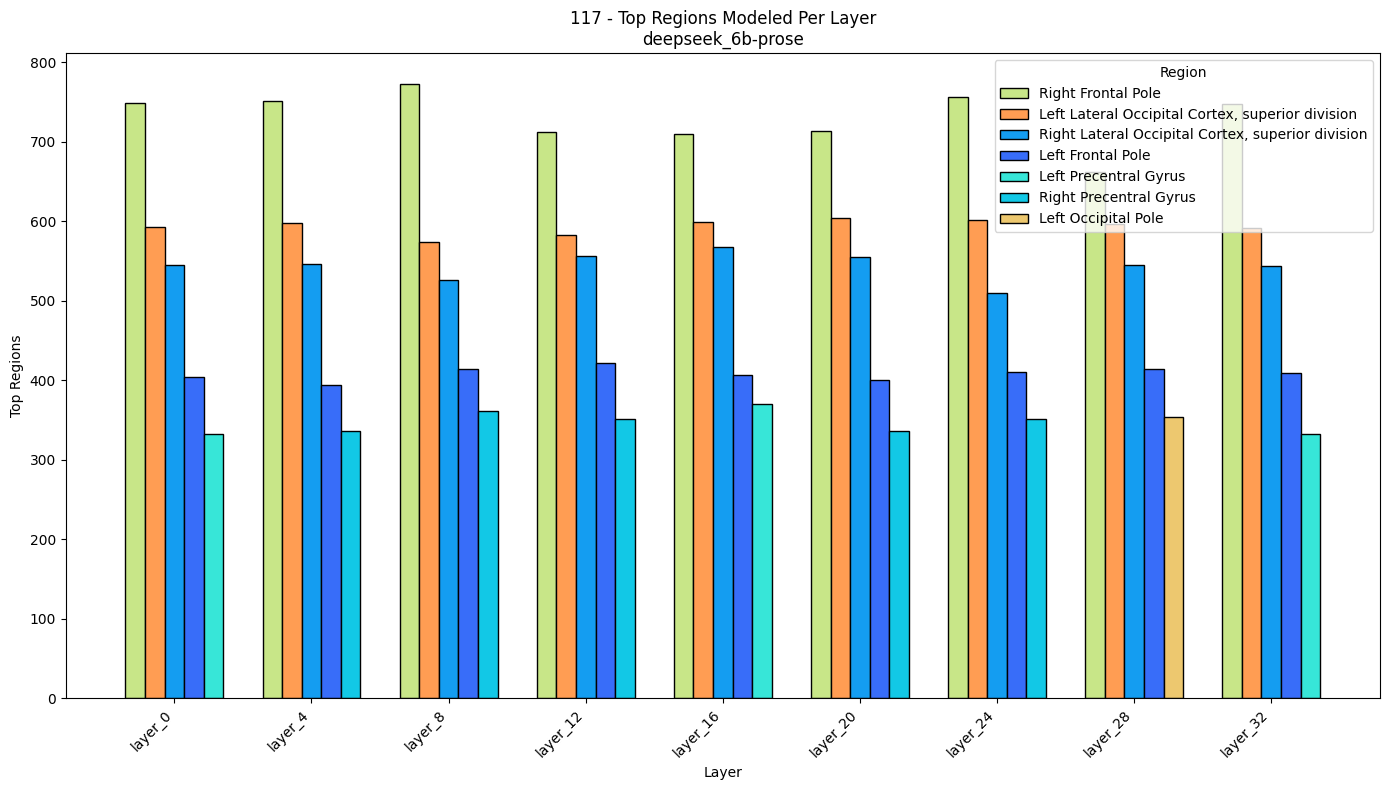

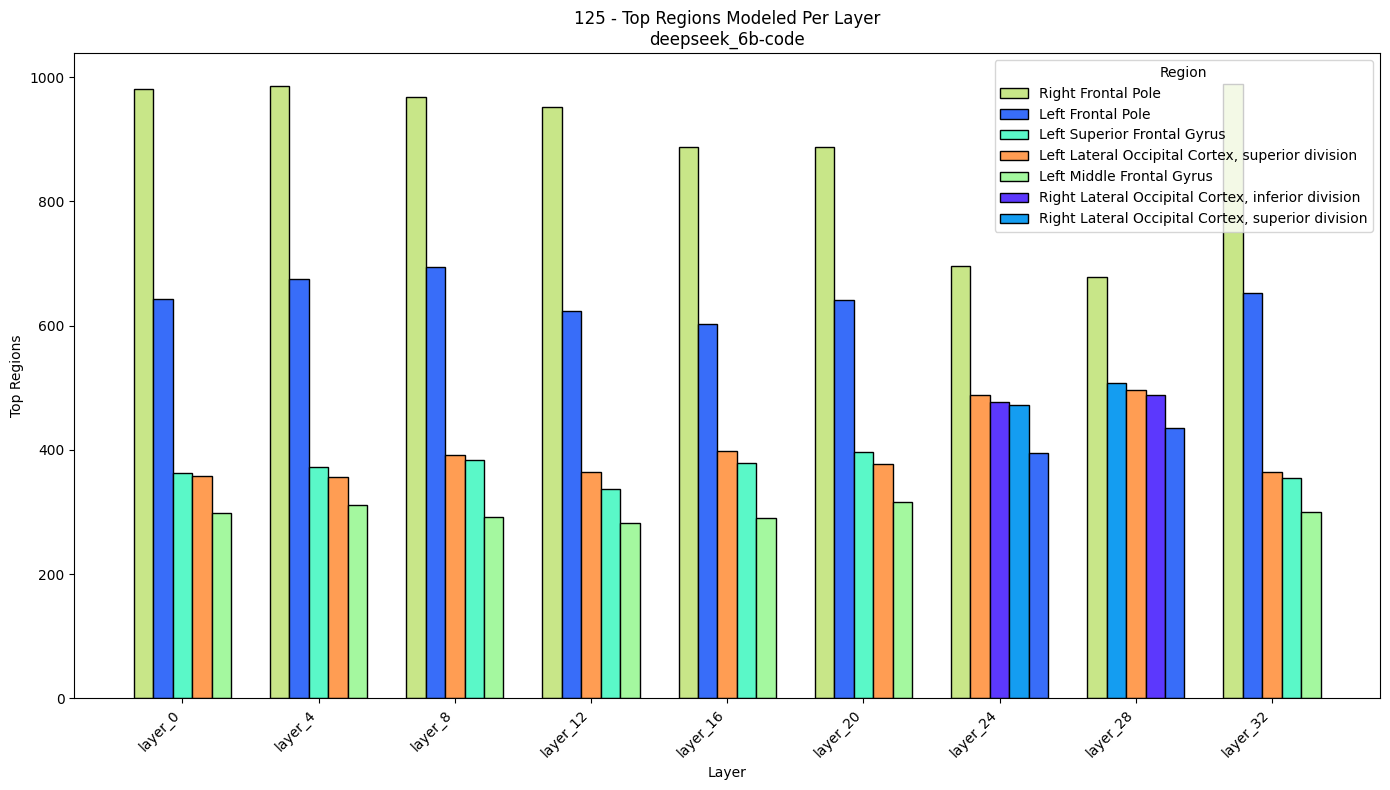

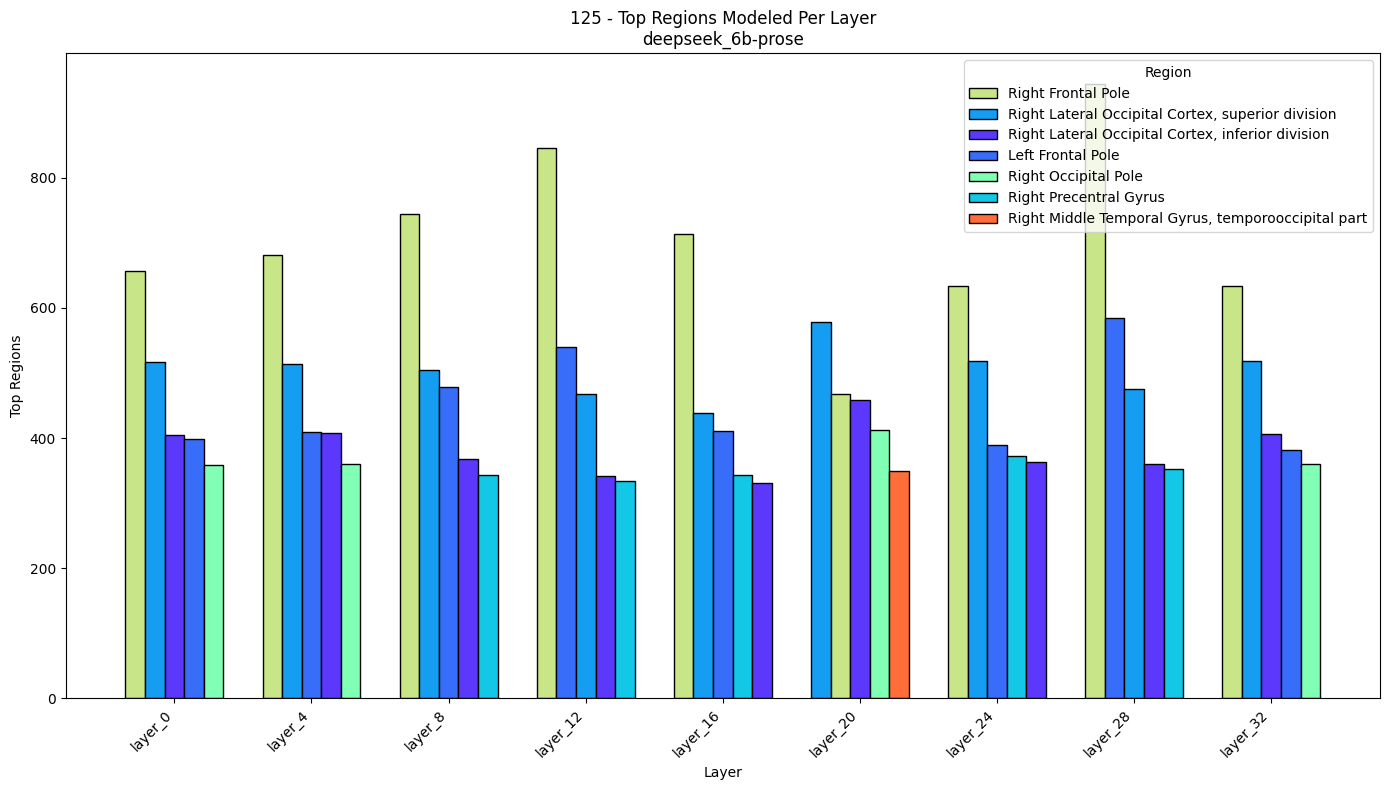

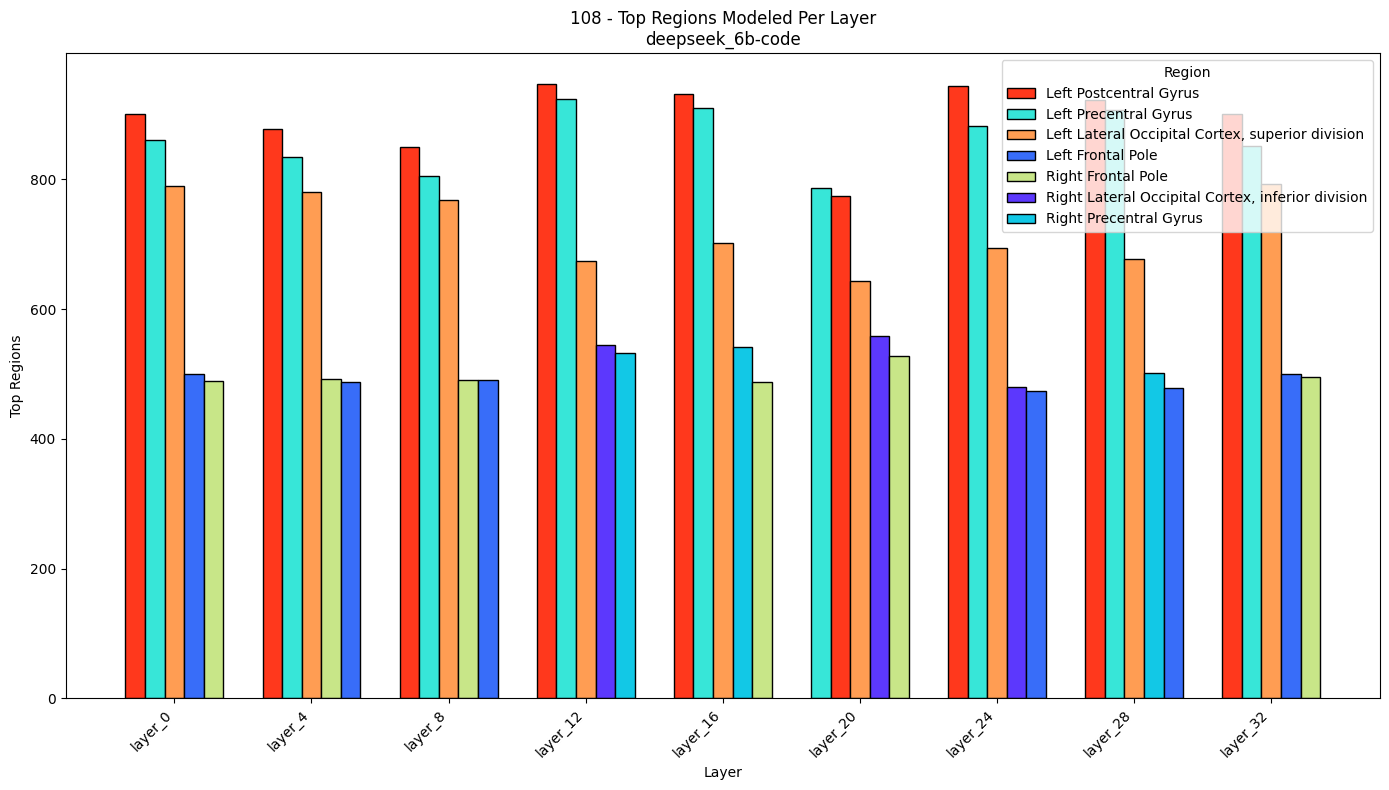

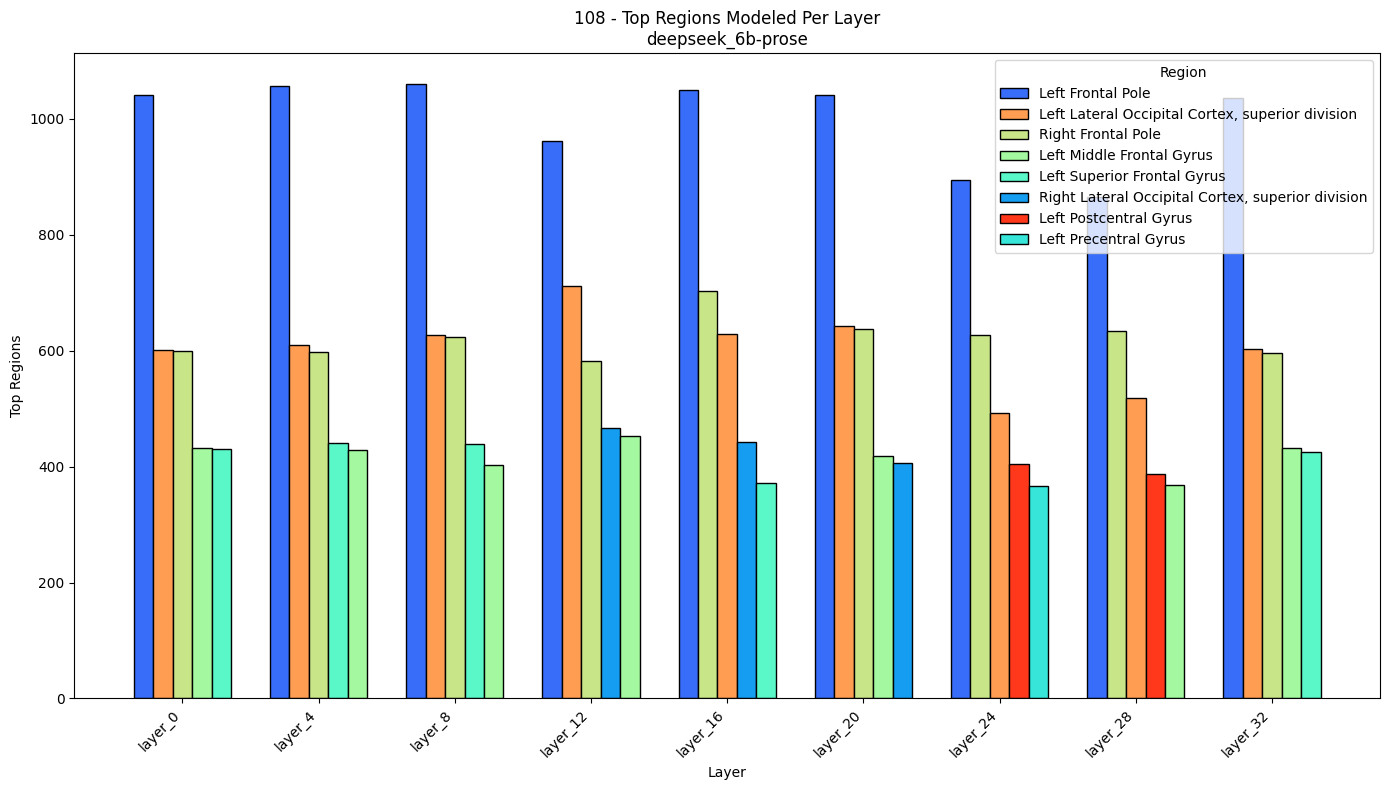

In [ ]:

for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))

        plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors)


In [24]:
df.to_csv("temp.csv")

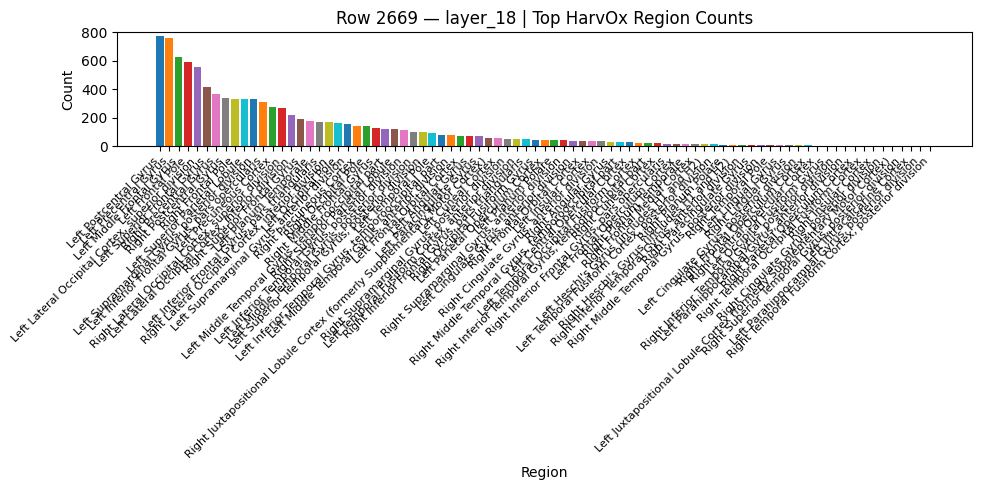

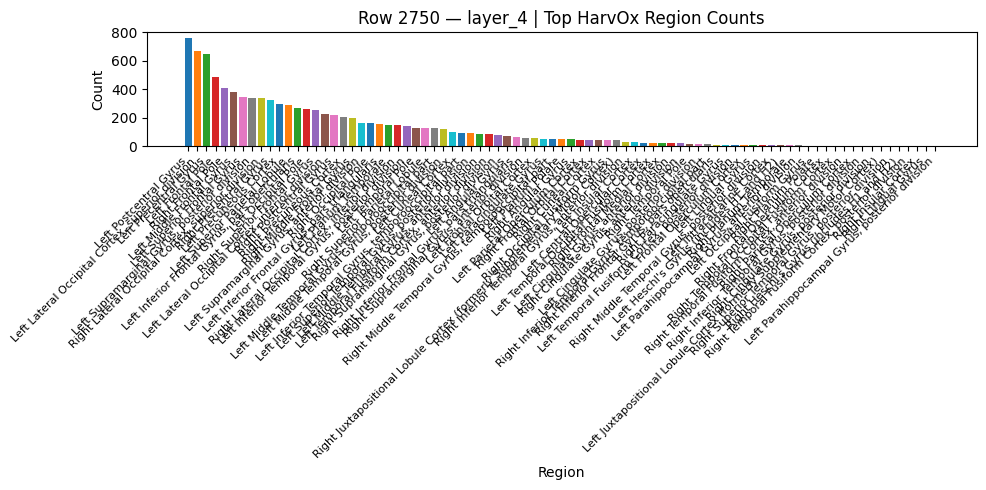

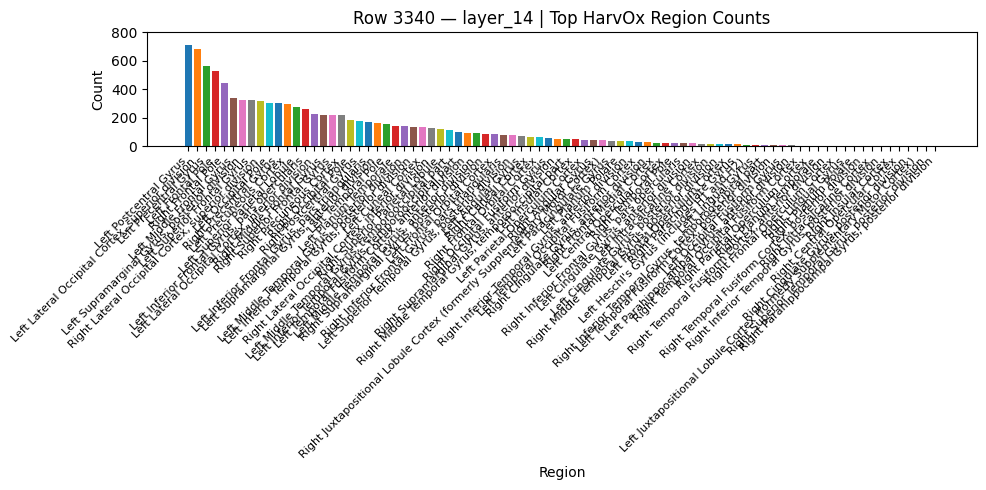

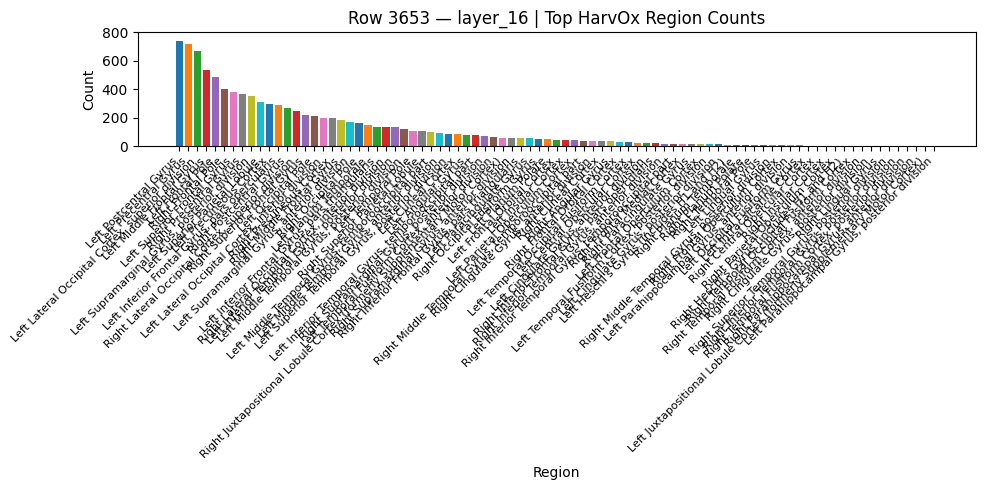

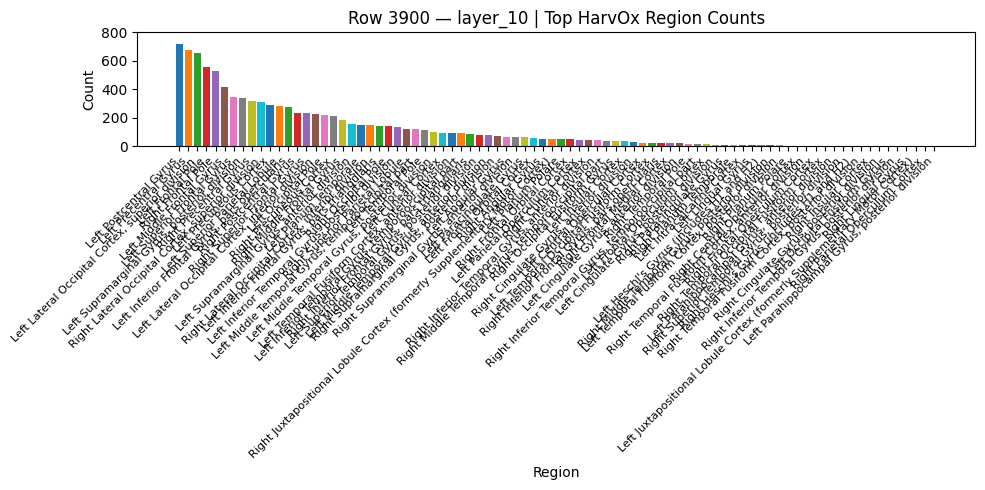

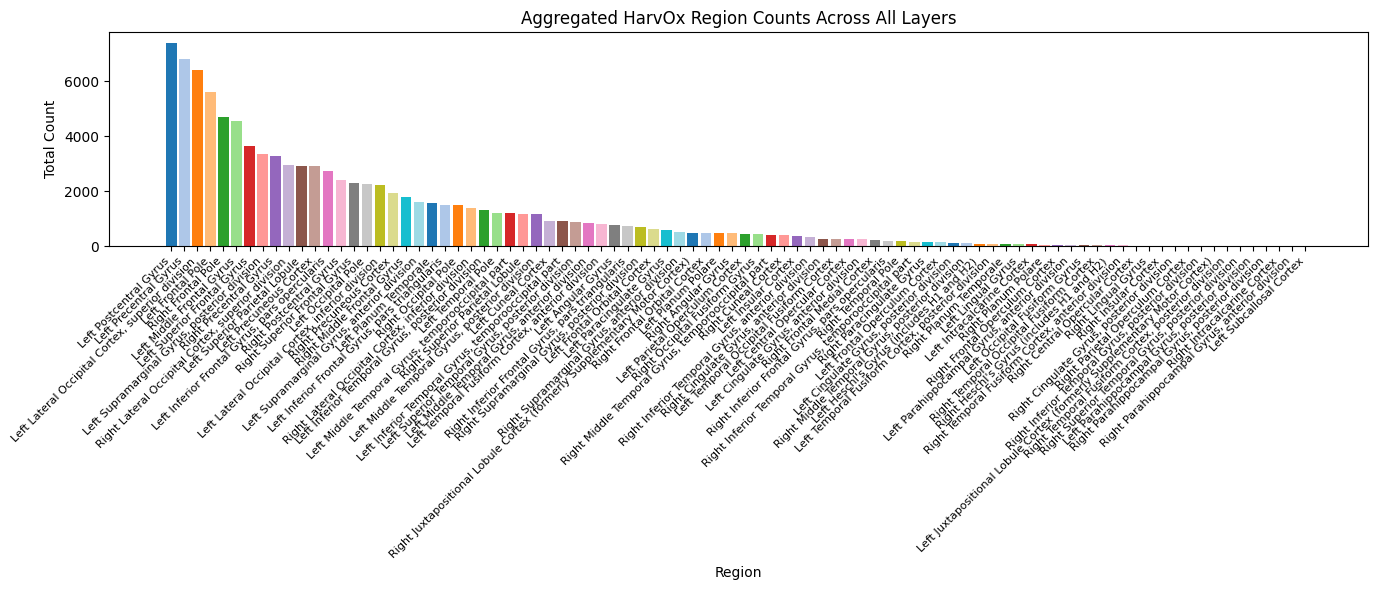

In [23]:

# Individual plot per row (first 5)
for idx, row in df.head(5).iterrows():
    region_counts = row['top_HarvOx_regions']
    sorted_regions = sorted(region_counts.items(), key=lambda x: x[1], reverse=True)
    regions, counts = zip(*sorted_regions) if sorted_regions else ([], [])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(regions)), counts, color=sns.color_palette("tab10", len(regions)))
    ax.set_xticks(range(len(regions)))
    ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Row {idx} — {row.get('layer', '')} | Top HarvOx Region Counts")
    ax.set_ylabel("Count")
    ax.set_xlabel("Region")
    ax.set_ylim([0,800])
    plt.tight_layout()
    plt.show()

# Aggregated across all layers
aggregated = Counter()
for region_counts in df['top_HarvOx_regions']:
    aggregated.update(region_counts)

sorted_agg = sorted(aggregated.items(), key=lambda x: x[1], reverse=True)
regions, counts = zip(*sorted_agg)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(regions)), counts, color=sns.color_palette("tab20", len(regions)))
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
ax.set_title("Aggregated HarvOx Region Counts Across All Layers")
ax.set_ylabel("Total Count")
# ax.set_ylim([0,800])
ax.set_xlabel("Region")
plt.tight_layout()
plt.show()
